# Homework 5: Neural Networks with Keras

### Imports

In [64]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.wrappers import SKLearnClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.compose import make_column_selector, ColumnTransformer

from plotting_helper import plot_loss_and_accuracy

In [ ]:
df = pd.read_csv("adult.csv")

In [11]:
df.head(2)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K


### Preprocessing

In [66]:
df.dropna(inplace=True)

X = df.drop(["income", "fnlwgt"], axis=1)

# Label Encode Y
y = df["income"]
y = LabelEncoder().fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, stratify=y, random_state=42)

# One Hot Encode X
ct_X = ColumnTransformer([
    ("ohe", OneHotEncoder(sparse_output=False), make_column_selector(dtype_include=object)),
    ("scale", StandardScaler(), make_column_selector(dtype_include=np.number))
], remainder='passthrough')
X_train = ct_X.fit_transform(X_train)
X_test = ct_X.transform(X_test)

In [56]:
X_train.shape

(39073, 107)

X has 107 columns, so the model will have 107 inputs

### Baseline Neural Network

In [57]:
inputs = keras.Input(shape=(X_train.shape[1],))
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(2, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="census_model")
model.summary()

Model: "census_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 107)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         6,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,234 (43.88 KB)

 Trainable params: 11,234 (43.88 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history = model.fit(
    X_train, 
    y_train,
    batch_size=64,
    epochs=50,
    validation_split=.2,
    verbose=1
)

scores = model.evaluate(X_test, y_test, verbose=1)

Epoch 1/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8422 - loss: 0.3358 - val_accuracy: 0.8471 - val_loss: 0.3237
Epoch 2/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - accuracy: 0.8564 - loss: 0.3067 - val_accuracy: 0.8532 - val_loss: 0.3169
Epoch 3/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - accuracy: 0.8589 - loss: 0.3012 - val_accuracy: 0.8535 - val_loss: 0.3203
Epoch 4/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step - accuracy: 0.8616 - loss: 0.2977 - val_accuracy: 0.8518 - val_loss: 0.3178
Epoch 5/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 923us/step - accuracy: 0.8615 - loss: 0.2947 - val_accuracy: 0.8502 - val_loss: 0.3221
Epoch 6/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - accuracy: 0.8643 - loss: 0.2912 - val_accuracy: 0.8540 - val_loss: 0.3215
Epoch 7/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - accuracy: 0.8653 - loss: 0.2885 - val_accuracy: 0.8523 - val_loss: 0.3204
Epoch 8/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - accuracy: 0.8673 - loss: 0.2849 - va

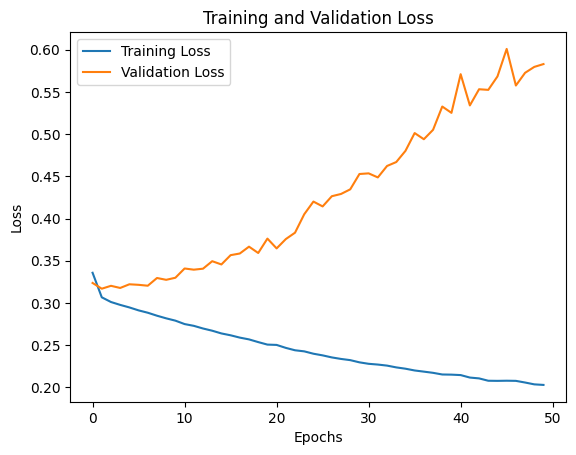

(None, None)

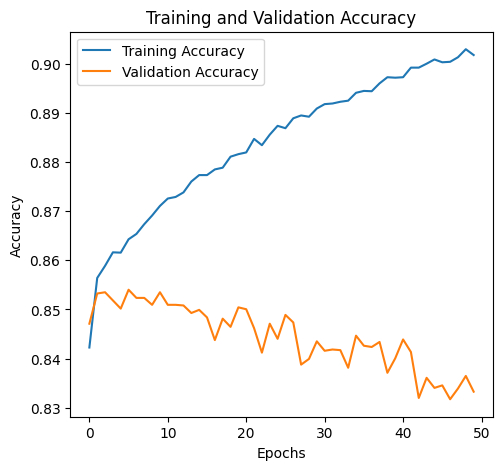

In [59]:
plot_loss_and_accuracy(history)

This is my baseline model, and as you can see, the model is really overfitting immediately.  My assumption is that my model has way too much capacity (over 11k parameters), 3 hidden layers, and 162 neurons.  In the `Model Improvements` section, I will use GridSearchCV optuna to find a more optimal level of parameters

### Model Improvements

Keras has a built-in SKLearnClassifier wrapper, so I can use grid search directly.  I will tune based on hidden layer configurations, epochs, dropout rates (0 vs .2), and early stopping (patience=3).

In [61]:
def build_model(X, y, hidden_layers=(32, 16), dropout_rate=0.0, learning_rate=.001):
    inputs = keras.Input(shape=(X.shape[1],))
    x = inputs

    for layer in hidden_layers:
        x = layers.Dense(layer, activation='relu')(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(y.shape[1], activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.CategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    return model

In [67]:
clf = SKLearnClassifier(
    model=build_model,
    fit_kwargs={
        "verbose": 1
    }
)

408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 486us/step
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 465us/step
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step
407/407 ━━━

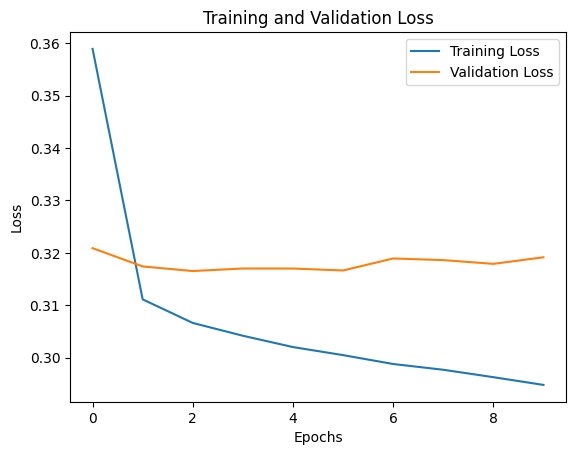

(None, None)

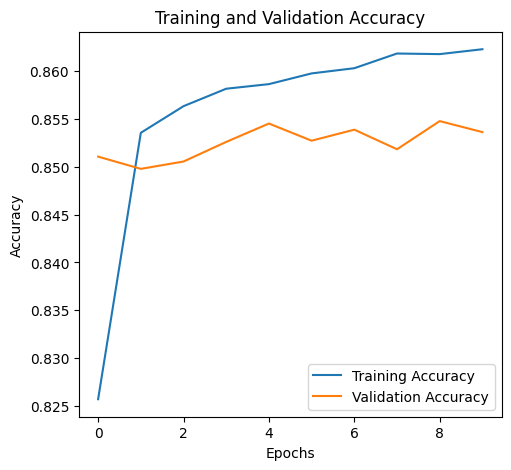

In [68]:
hidden_layer_configs = [
        {"hidden_layers": (32,)},
        {"hidden_layers": (16, 16)},
        {"hidden_layers": (8, 8, 8)},
        {"hidden_layers": (32, 16, 8)},
        {"hidden_layers": (8, 16, 32)},
        {"hidden_layers": (24, 12, 16)}
]

dropout_rates = [0.0, 0.2]

def make_early_stopping():
    return keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

fit_configs = [
    {"epochs": 10, "batch_size": 64, "validation_split": 0.2, "verbose": 0},
    {"epochs": 20, "batch_size": 64, "validation_split": 0.2, "verbose": 0},
]

param_grid = {
    "model_kwargs": [
        {**config, "dropout_rate": dropout_rate}
        for config in hidden_layer_configs
        for dropout_rate in dropout_rates
    ],
    "fit_kwargs": [
        {**config, "callbacks": []}
        for config in fit_configs
    ] + [
        {**config, "callbacks": [make_early_stopping()]}
        for config in fit_configs
    ]
}

grid = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=1
)

grid.fit(X_train, y_train)
best_gscv_model = grid.best_estimator_
history = best_gscv_model.history_
plot_loss_and_accuracy(history)

Using `GridSearchCV` with a keras `SKLearnClassifier` wrapper, we get the above plots.  The validation metrics seem to be independent of epochs and training metrics; both validation loss and accuracy stay somewhat constant for the 10 epochs.  This is 1-2% better (in terms of validation accuracy), but using `GridSearchCV` in this way poses an issue: we have to pass in and have an idea of good model parameters, instead of the search being able to find good parameters.  For this reason, I will pivot to `optuna` for tuning instead, and hope that the internal optimization finds a better model than the grid search.

In [70]:
# tuning the model with Optuna

def objective(trial):
    num_layers = trial.suggest_int("num_layers", 1, 4)  # number of hidden layers
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)  # log scale for LR
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])  # common batch sizes
    dropout_rate = trial.suggest_categorical("dropout_rate", [0, .2])
    epochs = trial.suggest_int("epochs", 5, 25)
    use_early_stopping = trial.suggest_categorical("use_early_stopping", [False, True])

    keras.backend.clear_session()
    tf.random.set_seed(42)

    inputs = keras.Input(shape=(X_train.shape[1],))  # 6 input features
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 4, 32)  # neurons per layer
        x = layers.Dense(units, activation="relu")(x)  # hidden layer
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(2, activation="softmax")(x)  # 2 classes → softmax output
    model = keras.Model(inputs=inputs, outputs=outputs)  # build model

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # classification loss
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),  # optimizer with tuned LR
        metrics=["accuracy"],  # track accuracy
    )

    callbacks = []
    if use_early_stopping:
        callbacks.append(
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )
        )

    use_early_stopping = trial.suggest_categorical("use_early_stopping", [False, True])

    history = model.fit(
        X_train,
        y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_split=.2,
        verbose=0,
        callbacks=callbacks
    )

    return min(history.history["val_loss"])  # objective = best validation loss


study = optuna.create_study(direction="minimize")  # minimize validation loss
study.optimize(objective, n_trials=20)  # run 20 trials (20 models)

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)


[I 2026-05-17 23:34:36,521] A new study created in memory with name: no-name-2f1689bc-b5d6-46ac-855d-e53597c45e46
[I 2026-05-17 23:34:44,216] Trial 0 finished with value: 0.31769412755966187 and parameters: {'num_layers': 1, 'learning_rate': 0.0007624553773777247, 'batch_size': 32, 'dropout_rate': 0.2, 'epochs': 7, 'use_early_stopping': False, 'num_units_layer_1': 20}. Best is trial 0 with value: 0.31769412755966187.
[I 2026-05-17 23:34:51,609] Trial 1 finished with value: 0.3188178241252899 and parameters: {'num_layers': 2, 'learning_rate': 0.00016507191776612545, 'batch_size': 64, 'dropout_rate': 0, 'epochs': 12, 'use_early_stopping': True, 'num_units_layer_1': 12, 'num_units_layer_2': 32}. Best is trial 0 with value: 0.31769412755966187.
[I 2026-05-17 23:35:10,483] Trial 2 finished with value: 0.3161640763282776 and parameters: {'num_layers': 2, 'learning_rate': 0.0002211132182877505, 'batch_size': 32, 'dropout_rate': 0, 'epochs': 21, 'use_early_stopping': True, 'num_units_layer_1':

Best validation loss: 0.31387433409690857
Best parameters: {'num_layers': 2, 'learning_rate': 0.0003200118207161613, 'batch_size': 32, 'dropout_rate': 0, 'epochs': 18, 'use_early_stopping': True, 'num_units_layer_1': 32, 'num_units_layer_2': 27}


I like optuna more for neural networks, because I have no clue what good parameters to input into the parameter grid for `GridSearchCV`.  It's nice that optuna handles this selection of parameters internally.

### Final Model Evaluation

Epoch 1/18
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8237 - loss: 0.3782 - val_accuracy: 0.8479 - val_loss: 0.3245
Epoch 2/18
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 918us/step - accuracy: 0.8529 - loss: 0.3137 - val_accuracy: 0.8507 - val_loss: 0.3185
Epoch 3/18
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - accuracy: 0.8551 - loss: 0.3080 - val_accuracy: 0.8530 - val_loss: 0.3166
Epoch 4/18
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 997us/step - accuracy: 0.8569 - loss: 0.3052 - val_accuracy: 0.8521 - val_loss: 0.3159
Epoch 5/18
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 887us/step - accuracy: 0.8577 - loss: 0.3034 - val_accuracy: 0.8523 - val_loss: 0.3157
Epoch 6/18
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 859us/step - accuracy: 0.8591 - loss: 0.3019 - val_accuracy: 0.8527 - val_loss: 0.3156
Epoch 7/18
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 863us/step - accuracy: 0.8592 - loss: 0.3008 - val_accuracy: 0.8534 - val_loss: 0.3157
Epoch 8/18
977/977 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - accuracy: 0.8598 - loss: 0.2997 - va

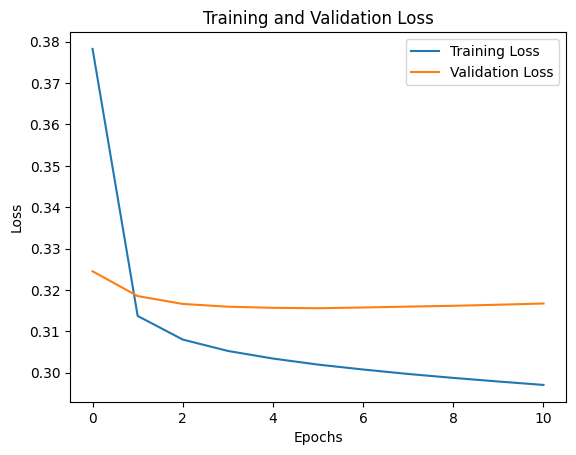

(None, None)

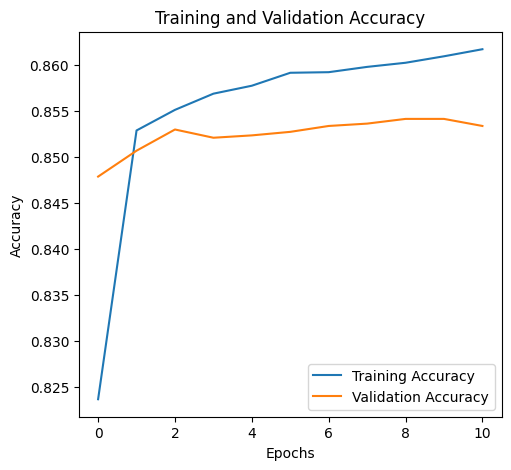

In [79]:
# Building the best model from Optuna results
best_params = study.best_params
num_layers = best_params["num_layers"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]
dropout_rate = best_params.get("dropout_rate", 0)
epochs = best_params.get("epochs", 50)
use_early_stopping = best_params.get("use_early_stopping", False)

tf.random.set_seed(42)

inputs = keras.Input(shape=(X_train.shape[1],))
x = inputs
for i in range(num_layers):
    units = best_params[f"num_units_layer_{i+1}"]
    x = layers.Dense(units, activation="relu")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
outputs = layers.Dense(2, activation="softmax")(x)
best_model = keras.Model(inputs=inputs, outputs=outputs)
best_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=["accuracy"],
)

callbacks = []
if use_early_stopping:
    callbacks.append(
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    )

history = best_model.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    verbose=1,
    callbacks=callbacks
)
scores = best_model.evaluate(X_test, y_test, verbose=1)

# evaluate the best model using the test set
y_pred_prob = best_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
y_pred_prob_positive = y_pred_prob[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob_positive)
print("\n Best Model Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

plot_loss_and_accuracy(history)


The best optuna model has plots that look much better than my baseline model:  The validation loss decreases over time, while the validation accuracy increases over time.  However, it seems like this model is powerful enough that the validation loss is minimized around 4 epochs, and it starts to rise after.  Regardless, I am happy with the optuna tuning.
| Type | Train Loss | Test Loss | Train Accuracy | Test Accuracy |
| - | - | - | - | - |
| Baseline Model | 0.2030 | 0.5545 | 0.9017 | 0.8433 |
| `GridSearchCV` | 0.3032 | 0.3114 | 0.8593 | 0.8588 |
| Optuna | 0.2970 | 0.3107 | 0.8617 | 0.8584 |

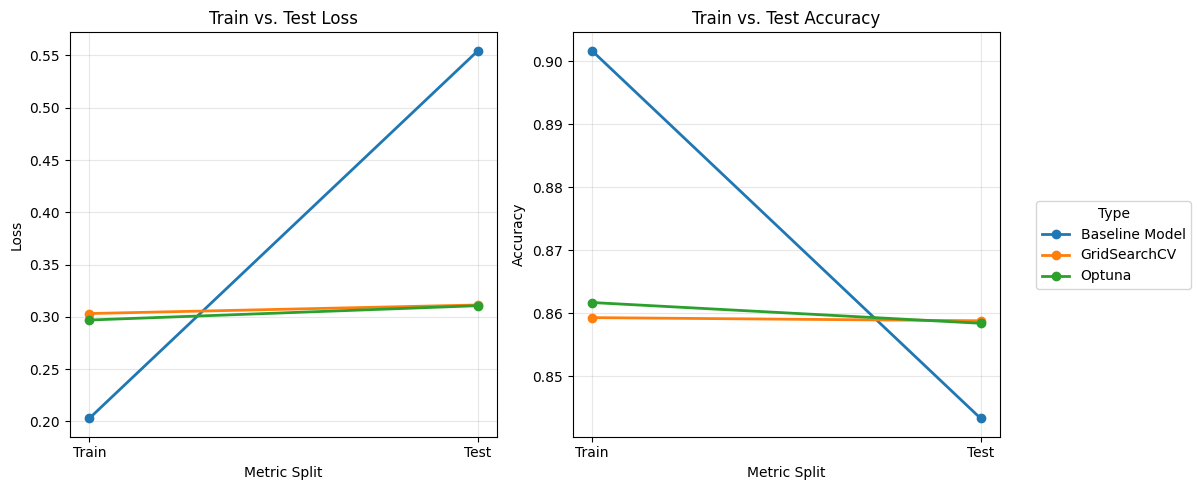

In [84]:
import importlib
import plotting_helper

plotting_helper = importlib.reload(plotting_helper)
plotting_helper.plot_loss_and_accuracy_lines()

The `GridSearchCV` model performed surprisingly similar to the optuna model, trailing slightly in all categories except for test accuracy (although it doesn't have a significant lead).  As we saw previously, the baseline model greatly overfitted, which is why its training metrics are drasticly better than the tuned models and its testing metrics are drastically worse.

### Personal Workflow

I honestly think that the optuna cell you provided us in the in-class activity for May 14 is such a good, simple workflow (pasted below, adapted for this homework's data and generalized for other data).

I've found Keras extremely easy to work with.  It literally has 3 steps:
1. Define the model architecture
2. Compile the model with an optimizer, a loss function, and any metrics to calculate
3. Fit the model, passing in training data, batch size, epochs, validation split, and verbosity.

The preprocessing is the exact same as sklearn, so there is no learning curve there.  I've been thoroughly impressed with Keras; even more so given that they are implementing pytorch backend support.

```python
# tuning the model with Optuna

def objective(trial):
    num_layers = trial.suggest_int("num_layers", 1, 4)  # number of hidden layers
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)  # log scale for LR
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])  # common batch sizes
    dropout_rate = trial.suggest_categorical("dropout_rate", [0, .2])
    epochs = trial.suggest_int("epochs", 5, 25)
    use_early_stopping = trial.suggest_categorical("use_early_stopping", [False, True])

    keras.backend.clear_session()
    tf.random.set_seed(42)

    inputs = keras.Input(shape=(X_train.shape[1],))  # 6 input features
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 4, 32)  # neurons per layer
        x = layers.Dense(units, activation="relu")(x)  # hidden layer
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(2, activation="softmax")(x)  # 2 classes → softmax output
    model = keras.Model(inputs=inputs, outputs=outputs)  # build model

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # classification loss
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),  # optimizer with tuned LR
        metrics=["accuracy"],  # track accuracy
    )

    callbacks = []
    if use_early_stopping:
        callbacks.append(
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )
        )

    use_early_stopping = trial.suggest_categorical("use_early_stopping", [False, True])

    history = model.fit(
        X_train,
        y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_split=.2,
        verbose=0,
        callbacks=callbacks
    )

    return min(history.history["val_loss"])  # objective = best validation loss


study = optuna.create_study(direction="minimize")  # minimize validation loss
study.optimize(objective, n_trials=20)  # run 20 trials (20 models)

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)

```